In [1]:
import numpy as np   
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('cleaned_lalpurja_land.csv')

In [3]:
df_lp=df.copy()

In [4]:
df.sample(5)

,district,property_type,property_face,road_type,negotiable,views,municipality,ward_no,neighborhood,price_per_aana,...,hospital_m,airport_m,pharmacy_m,bhatbhateni_m,school_m,public_transport_m,police_station_m,pashupatinath_m,boudhanath_m,ring_road_m
819,Lalitpur,Residential,South-West,High Access,Yes,346,Lalitpur,18,Bhaisepati,4000000.0,...,1500.0,11000.0,500.0,5000.0,4000.0,650.0,2000.0,11000.0,13000.0,2500.0
113,Kathmandu,Residential,Save Property,Low Access,Yes,127,Tokha,04,Tokha,4500000.0,...,400.0,4000.0,300.0,500.0,10.0,700.0,700.0,5000.0,5000.0,5.0
59,Kathmandu,Residential,North-East,High Access,Yes,153,Kageshwori Manohara,06,Jorpati,3800000.0,...,1000.0,7000.0,500.0,5000.0,1000.0,500.0,500.0,5000.0,3000.0,5000.0
693,Lalitpur,Residential,East,High Access,Yes,240,Mahalaxmi,07,Changathali,2900000.0,...,800.0,10000.0,400.0,700.0,400.0,20.0,360.0,14000.0,18000.0,6000.0
1221,Bhaktapur,Semi-commercial,North-East,Low Access,Yes,398,Bhaktapur,02,Duwakot,2000000.0,...,1000.0,11000.0,1000.0,4000.0,3000.0,4000.0,2000.0,10000.0,12000.0,5000.0


In [5]:
print("=== Basic Stats ===")
print(f"Shape: {df_lp.shape}")
print(f"\nprice_per_aana stats:")
print(df_lp['price_per_aana'].describe())

print(f"\nland_size_aana stats:")
print(df_lp['land_size_aana'].describe())

print(f"\n=== District distribution ===")
print(df_lp['district'].value_counts())

print(f"\n=== property_type distribution ===")
print(df_lp['property_type'].value_counts())

print(f"\n=== road_type distribution ===")
print(df_lp['road_type'].value_counts())

print(f"\n=== Price by district ===")
print(df_lp.groupby('district')['price_per_aana'].median().sort_values(ascending=False))

print(f"\n=== Price by property_type ===")
print(df_lp.groupby('property_type')['price_per_aana'].median().sort_values(ascending=False))

print(f"\n=== Correlation with price_per_aana ===")
num_cols = ['price_per_aana', 'land_size_aana', 'road_width_feet',
            'facing_road_width', 'hospital_m', 'airport_m',
            'school_m', 'ring_road_m', 'public_transport_m']
print(df_lp[num_cols].corr()['price_per_aana'].sort_values(ascending=False))


=== Basic Stats ===
Shape: (1260, 23)

price_per_aana stats:
count    1.260000e+03
mean     4.239365e+06
std      1.884582e+06
min      6.000000e+05
25%      2.800000e+06
50%      4.000000e+06
75%      5.500000e+06
max      9.900000e+06
Name: price_per_aana, dtype: float64

land_size_aana stats:
count    1260.000000
mean        8.185085
std         8.052974
min         1.000000
25%         4.000000
50%         5.205000
75%         8.500000
max        50.000000
Name: land_size_aana, dtype: float64

=== District distribution ===
district
Kathmandu    682
Lalitpur     297
Bhaktapur    281
Name: count, dtype: int64

=== property_type distribution ===
property_type
Residential        1006
Commercial          148
Semi-commercial     106
Name: count, dtype: int64

=== road_type distribution ===
road_type
High Access    757
Low Access     503
Name: count, dtype: int64

=== Price by district ===
district
Kathmandu    4400000.0
Lalitpur     3600000.0
Bhaktapur    3200000.0
Name: price_per_aana, 

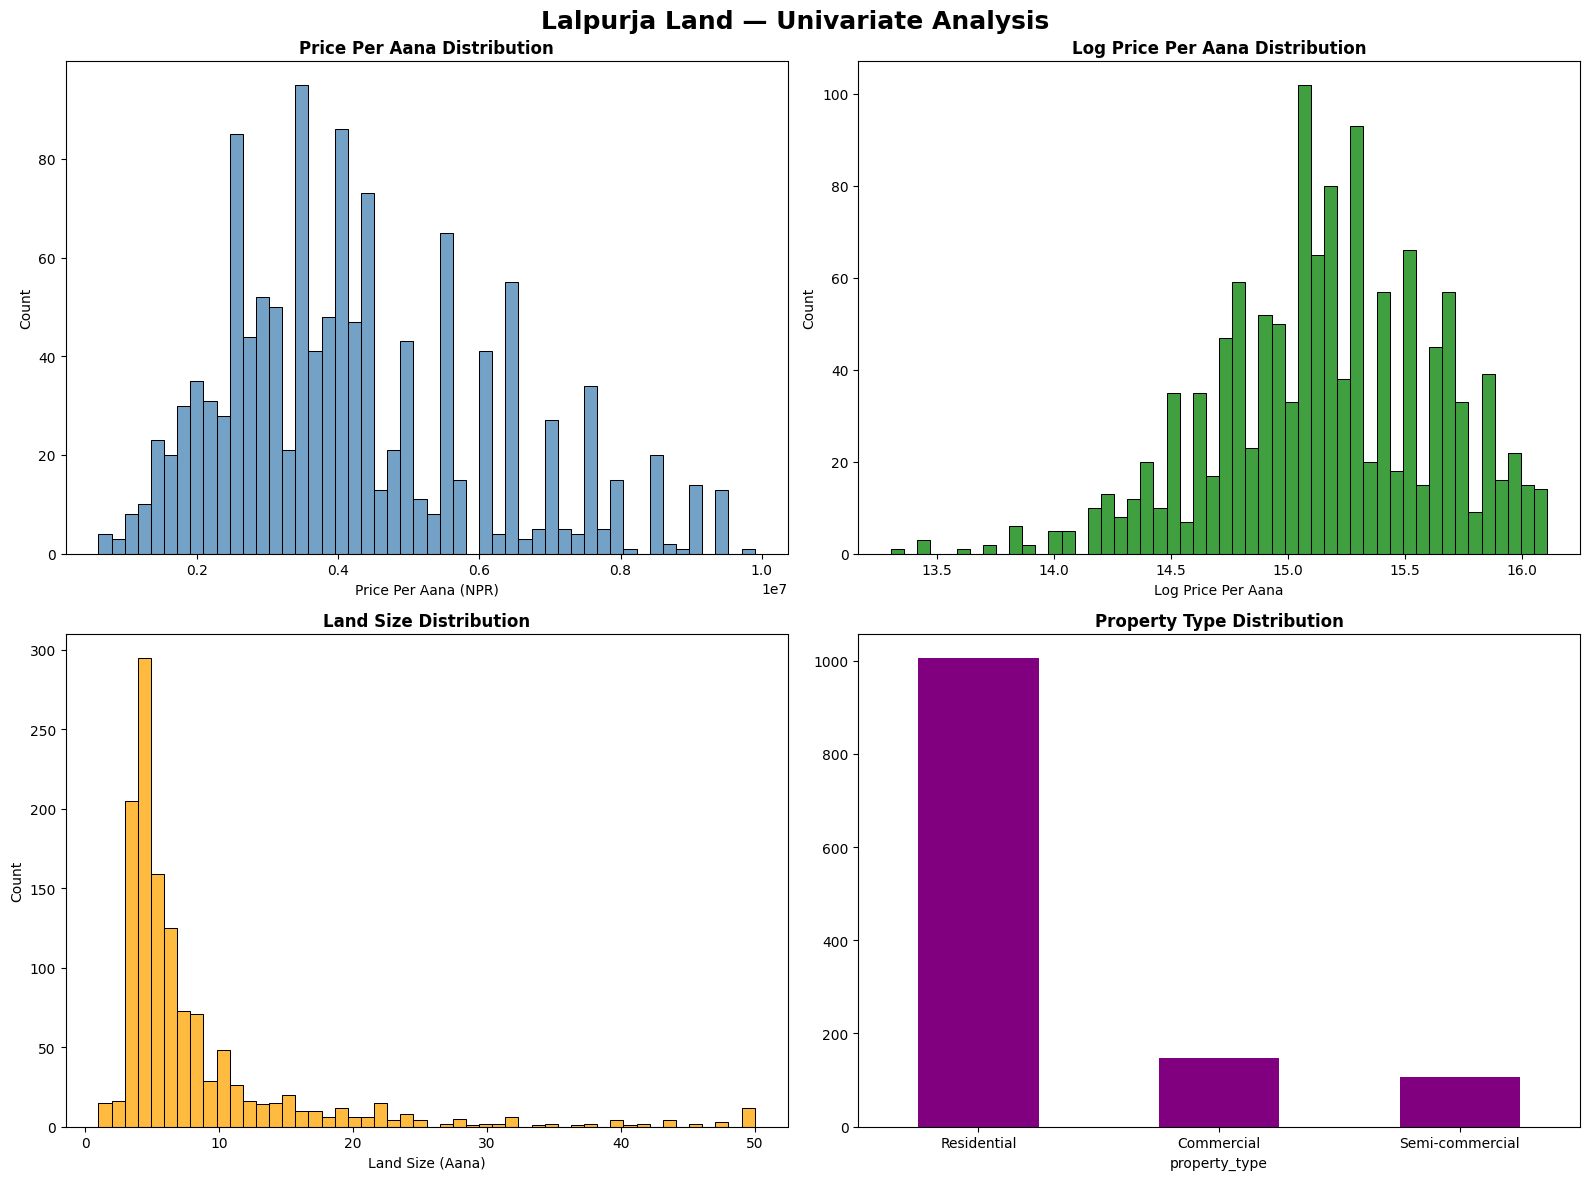

=== Price Per Aana Distribution ===
Skewness: 0.714
Log Skewness: -0.431

=== Land Size Distribution ===
Skewness: 3.098
Most common size: 4.0 aana


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Land — Univariate Analysis', fontsize=18, fontweight='bold')

# Plot 1 — price_per_aana distribution
# Why: See if price is skewed — determines if log transform is needed
sns.histplot(df_lp['price_per_aana'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Price Per Aana Distribution', fontweight='bold')
axes[0,0].set_xlabel('Price Per Aana (NPR)')

# Plot 2 — log price distribution
# Why: Log transform often normalizes skewed price data
# A bell shaped log distribution confirms log transform is appropriate
sns.histplot(np.log1p(df_lp['price_per_aana']), bins=50, ax=axes[0,1], color='green')
axes[0,1].set_title('Log Price Per Aana Distribution', fontweight='bold')
axes[0,1].set_xlabel('Log Price Per Aana')

# Plot 3 — land_size_aana distribution
# Why: Understand the typical plot size in this dataset
sns.histplot(df_lp['land_size_aana'], bins=50, ax=axes[1,0], color='orange')
axes[1,0].set_title('Land Size Distribution', fontweight='bold')
axes[1,0].set_xlabel('Land Size (Aana)')

# Plot 4 — property_type count
# Why: See balance between Residential, Commercial, Semi-commercial
df_lp['property_type'].value_counts().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Property Type Distribution', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Key stats
print("=== Price Per Aana Distribution ===")
print(f"Skewness: {df_lp['price_per_aana'].skew():.3f}")
print(f"Log Skewness: {np.log1p(df_lp['price_per_aana']).skew():.3f}")

print("\n=== Land Size Distribution ===")
print(f"Skewness: {df_lp['land_size_aana'].skew():.3f}")
print(f"Most common size: {df_lp['land_size_aana'].mode()[0]} aana")

C:\Users\DELL\AppData\Local\Temp\ipykernel_11236\2618525661.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lp, x='district', y='price_per_aana',
C:\Users\DELL\AppData\Local\Temp\ipykernel_11236\2618525661.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lp, x='property_type', y='price_per_aana',
C:\Users\DELL\AppData\Local\Temp\ipykernel_11236\2618525661.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lp, x='road_type', y='price_per_aana',


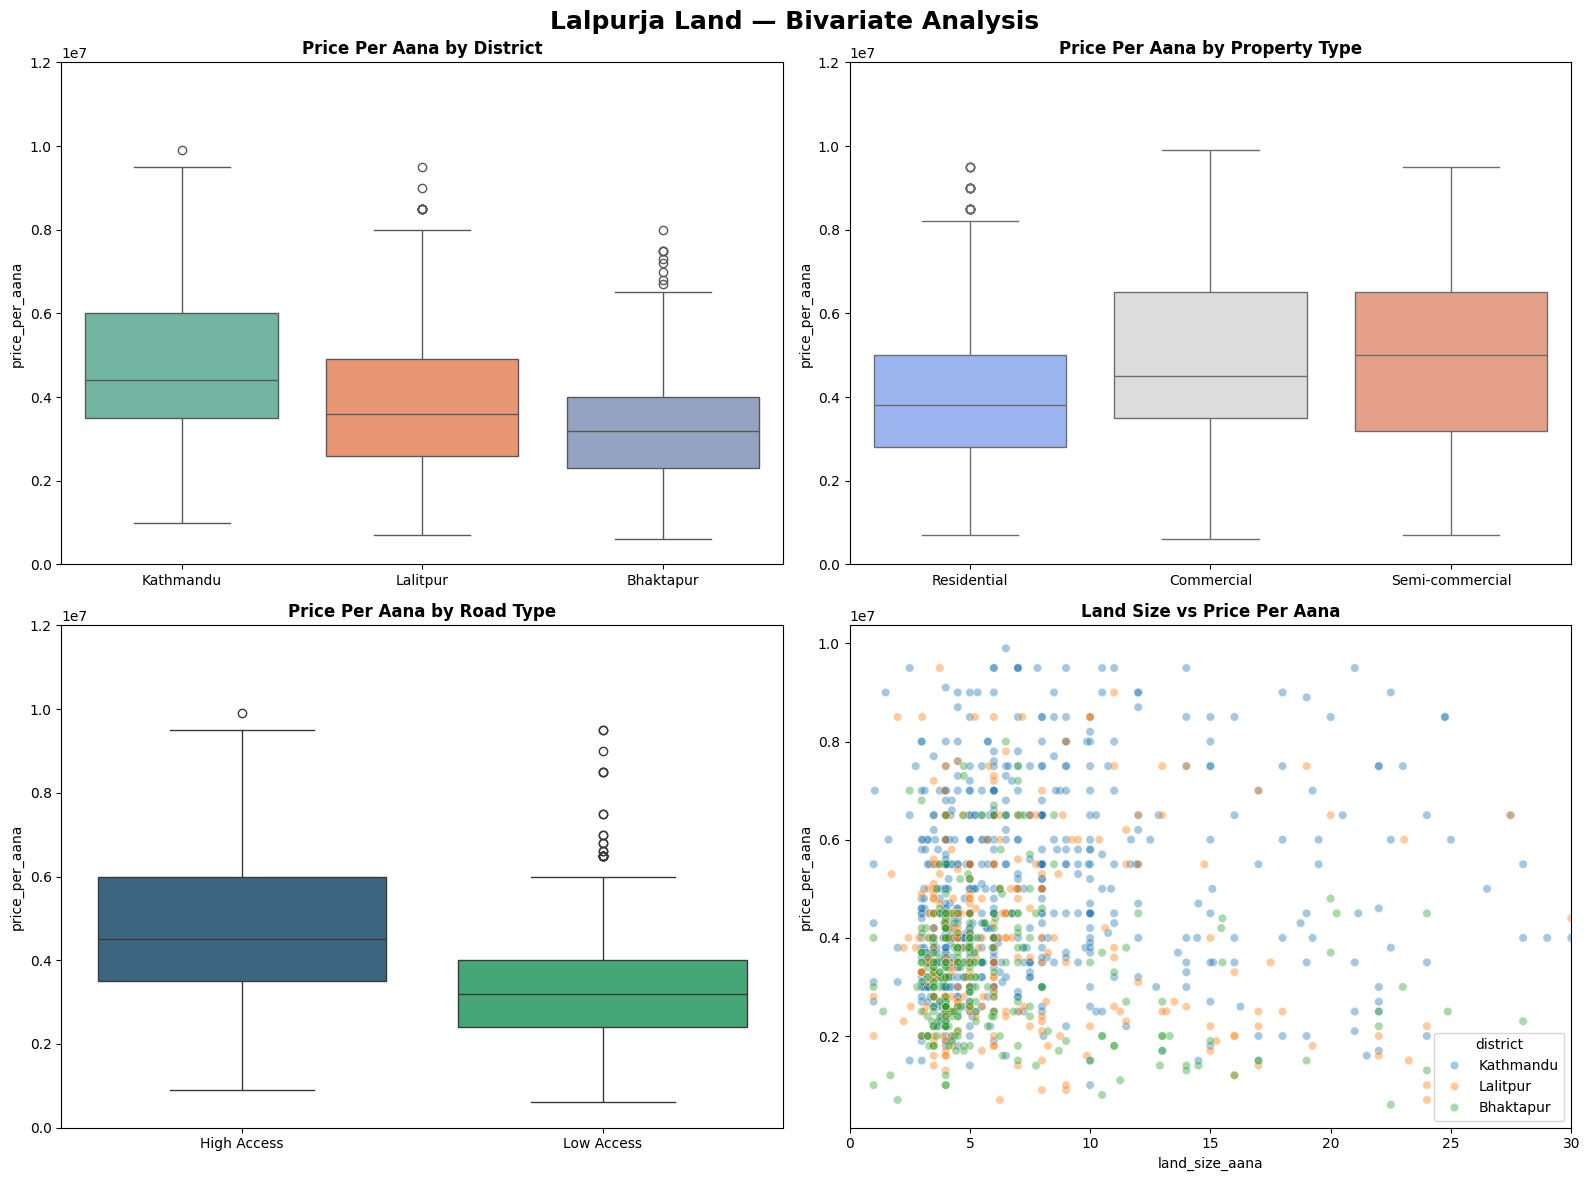

=== Price by District ===
district
Kathmandu    4400000.0
Lalitpur     3600000.0
Bhaktapur    3200000.0
Name: price_per_aana, dtype: float64

=== Price by Property Type ===
property_type
Semi-commercial    5000000.0
Commercial         4500000.0
Residential        3800000.0
Name: price_per_aana, dtype: float64

=== Price by Road Type ===
road_type
High Access    4500000.0
Low Access     3200000.0
Name: price_per_aana, dtype: float64

=== Land Size vs Price Correlation ===
Correlation: -0.0369


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Land — Bivariate Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Price by district
# Why: See which district commands highest price per aana
# and how spread out prices are within each district
sns.boxplot(data=df_lp, x='district', y='price_per_aana',
            ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Price Per Aana by District', fontweight='bold')
axes[0,0].set_ylim(0, 12000000)
axes[0,0].set_xlabel('')

# Plot 2 — Price by property_type
# Why: Check if Commercial/Semi-commercial commands premium
# over Residential — important for feature engineering
sns.boxplot(data=df_lp, x='property_type', y='price_per_aana',
            ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Price Per Aana by Property Type', fontweight='bold')
axes[0,1].set_ylim(0, 12000000)
axes[0,1].set_xlabel('')

# Plot 3 — Price by road_type
# Why: Check if High Access road commands premium over Low Access
sns.boxplot(data=df_lp, x='road_type', y='price_per_aana',
            ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Price Per Aana by Road Type', fontweight='bold')
axes[1,0].set_ylim(0, 12000000)
axes[1,0].set_xlabel('')

# Plot 4 — Land size vs price scatter
# Why: Visually confirm near-zero correlation between size and price
sns.scatterplot(data=df_lp, x='land_size_aana', y='price_per_aana',
                hue='district', ax=axes[1,1], alpha=0.4)
axes[1,1].set_title('Land Size vs Price Per Aana', fontweight='bold')
axes[1,1].set_xlim(0, 30)

plt.tight_layout()
plt.show()

# Key stats
print("=== Price by District ===")
print(df_lp.groupby('district')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Price by Property Type ===")
print(df_lp.groupby('property_type')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Price by Road Type ===")
print(df_lp.groupby('road_type')['price_per_aana'].median().sort_values(ascending=False))

print("\n=== Land Size vs Price Correlation ===")
print(f"Correlation: {df_lp['land_size_aana'].corr(df_lp['price_per_aana']):.4f}")

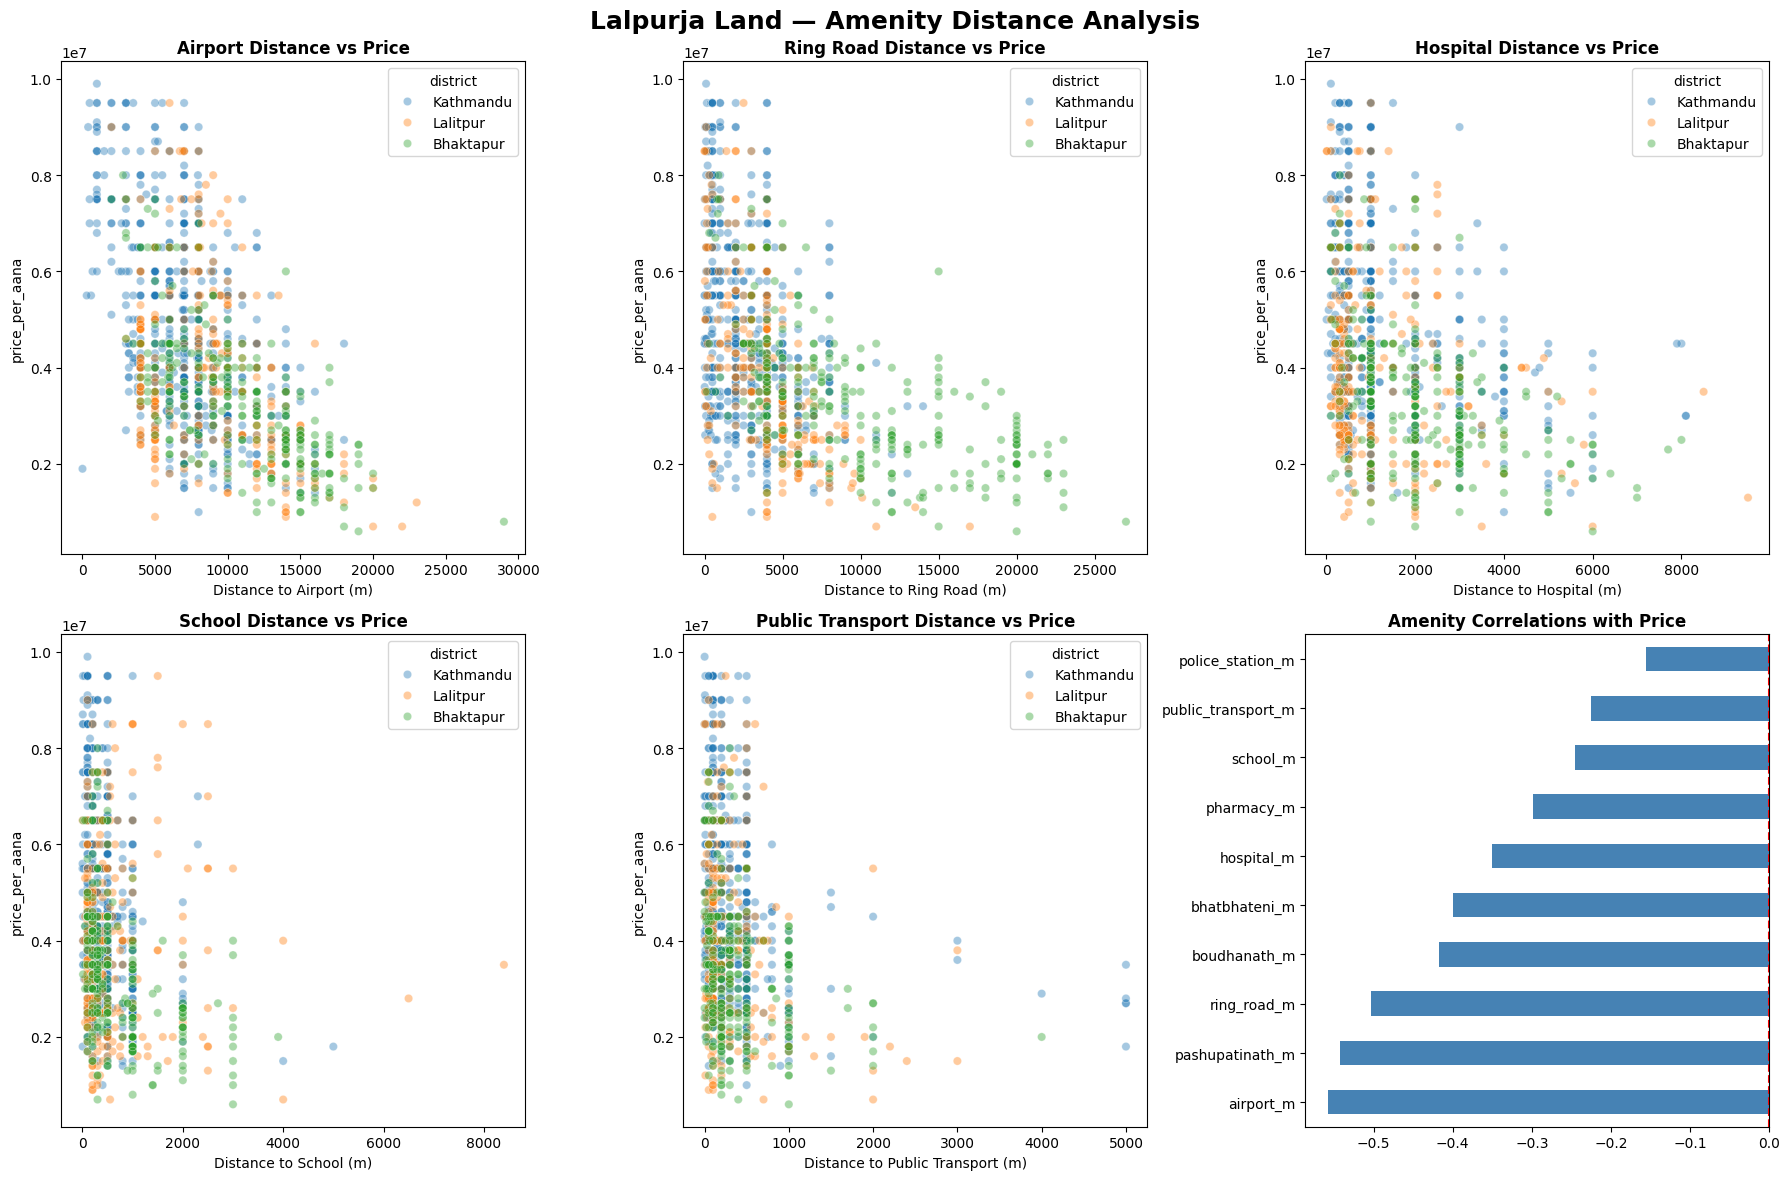

=== Amenity correlations with price_per_aana ===
airport_m            -0.558346
pashupatinath_m      -0.542142
ring_road_m          -0.503560
boudhanath_m         -0.417757
bhatbhateni_m        -0.399839
hospital_m           -0.350464
pharmacy_m           -0.298976
school_m             -0.246047
public_transport_m   -0.225380
police_station_m     -0.155549
dtype: float64

=== Average distances by district ===
           hospital_m  airport_m  pharmacy_m  bhatbhateni_m  school_m  \
district                                                                
Bhaktapur      2000.0    10000.0       300.0         3500.0     400.0   
Kathmandu      1000.0     7000.0       300.0         2500.0     300.0   
Lalitpur        600.0     8000.0       200.0         1000.0     300.0   

           public_transport_m  police_station_m  pashupatinath_m  \
district                                                           
Bhaktapur               250.0            1000.0          12000.0   
Kathmandu        

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Lalpurja Land — Amenity Distance Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Airport distance vs price
# Why: Airport had strongest correlation (-0.558)
# Closer to airport = more urban = higher price
sns.scatterplot(data=df_lp, x='airport_m', y='price_per_aana',
                hue='district', ax=axes[0,0], alpha=0.4)
axes[0,0].set_title('Airport Distance vs Price', fontweight='bold')
axes[0,0].set_xlabel('Distance to Airport (m)')

# Plot 2 — Ring road distance vs price
# Why: Ring road had second strongest correlation (-0.503)
# Properties near ring road are more accessible and urban
sns.scatterplot(data=df_lp, x='ring_road_m', y='price_per_aana',
                hue='district', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Ring Road Distance vs Price', fontweight='bold')
axes[0,1].set_xlabel('Distance to Ring Road (m)')

# Plot 3 — Hospital distance vs price
# Why: Hospital had third strongest correlation (-0.350)
# Proximity to hospital indicates urban infrastructure
sns.scatterplot(data=df_lp, x='hospital_m', y='price_per_aana',
                hue='district', ax=axes[0,2], alpha=0.4)
axes[0,2].set_title('Hospital Distance vs Price', fontweight='bold')
axes[0,2].set_xlabel('Distance to Hospital (m)')

# Plot 4 — School distance vs price
# Why: School had correlation of -0.246
# Families prefer plots near schools — drives demand
sns.scatterplot(data=df_lp, x='school_m', y='price_per_aana',
                hue='district', ax=axes[1,0], alpha=0.4)
axes[1,0].set_title('School Distance vs Price', fontweight='bold')
axes[1,0].set_xlabel('Distance to School (m)')

# Plot 5 — Public transport vs price
# Why: Public transport had correlation of -0.225
# Easy access to transport increases land value
sns.scatterplot(data=df_lp, x='public_transport_m', y='price_per_aana',
                hue='district', ax=axes[1,1], alpha=0.4)
axes[1,1].set_title('Public Transport Distance vs Price', fontweight='bold')
axes[1,1].set_xlabel('Distance to Public Transport (m)')

# Plot 6 — Correlation bar chart of all amenities
# Why: Visual summary of which amenity has strongest price impact
amenity_cols = ['hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m',
                'school_m', 'public_transport_m', 'police_station_m',
                'pashupatinath_m', 'boudhanath_m', 'ring_road_m']
corrs = df_lp[amenity_cols].corrwith(df_lp['price_per_aana']).sort_values()
corrs.plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Amenity Correlations with Price', fontweight='bold')
axes[1,2].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Key stats
print("=== Amenity correlations with price_per_aana ===")
print(corrs.sort_values())

print("\n=== Average distances by district ===")
print(df_lp.groupby('district')[amenity_cols].median().round(0))

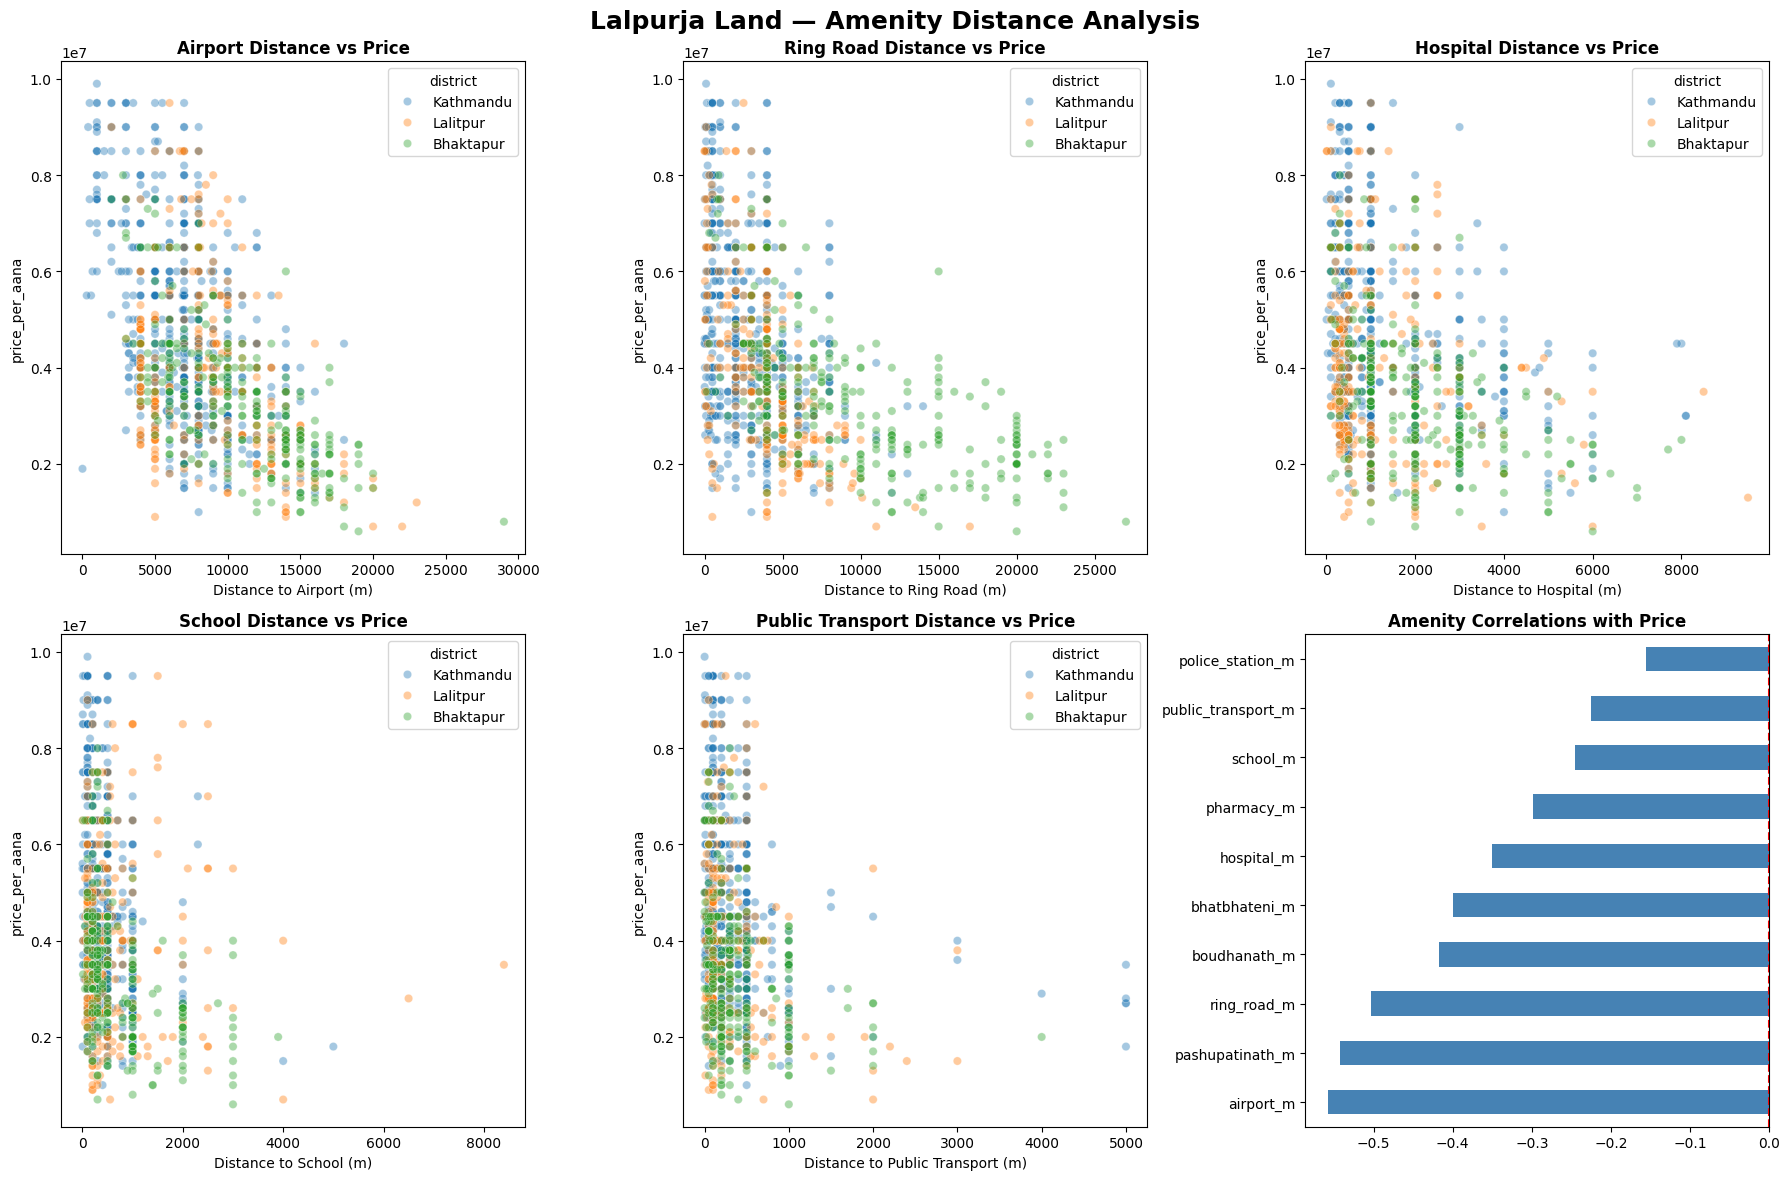

=== Amenity correlations with price_per_aana ===
airport_m            -0.558346
pashupatinath_m      -0.542142
ring_road_m          -0.503560
boudhanath_m         -0.417757
bhatbhateni_m        -0.399839
hospital_m           -0.350464
pharmacy_m           -0.298976
school_m             -0.246047
public_transport_m   -0.225380
police_station_m     -0.155549
dtype: float64

=== Average distances by district ===
           hospital_m  airport_m  pharmacy_m  bhatbhateni_m  school_m  \
district                                                                
Bhaktapur      2000.0    10000.0       300.0         3500.0     400.0   
Kathmandu      1000.0     7000.0       300.0         2500.0     300.0   
Lalitpur        600.0     8000.0       200.0         1000.0     300.0   

           public_transport_m  police_station_m  pashupatinath_m  \
district                                                           
Bhaktapur               250.0            1000.0          12000.0   
Kathmandu        

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Lalpurja Land — Amenity Distance Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Airport distance vs price
# Why: Airport had strongest correlation (-0.558)
# Closer to airport = more urban = higher price
sns.scatterplot(data=df_lp, x='airport_m', y='price_per_aana',
                hue='district', ax=axes[0,0], alpha=0.4)
axes[0,0].set_title('Airport Distance vs Price', fontweight='bold')
axes[0,0].set_xlabel('Distance to Airport (m)')

# Plot 2 — Ring road distance vs price
# Why: Ring road had second strongest correlation (-0.503)
# Properties near ring road are more accessible and urban
sns.scatterplot(data=df_lp, x='ring_road_m', y='price_per_aana',
                hue='district', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Ring Road Distance vs Price', fontweight='bold')
axes[0,1].set_xlabel('Distance to Ring Road (m)')

# Plot 3 — Hospital distance vs price
# Why: Hospital had third strongest correlation (-0.350)
# Proximity to hospital indicates urban infrastructure
sns.scatterplot(data=df_lp, x='hospital_m', y='price_per_aana',
                hue='district', ax=axes[0,2], alpha=0.4)
axes[0,2].set_title('Hospital Distance vs Price', fontweight='bold')
axes[0,2].set_xlabel('Distance to Hospital (m)')

# Plot 4 — School distance vs price
# Why: School had correlation of -0.246
# Families prefer plots near schools — drives demand
sns.scatterplot(data=df_lp, x='school_m', y='price_per_aana',
                hue='district', ax=axes[1,0], alpha=0.4)
axes[1,0].set_title('School Distance vs Price', fontweight='bold')
axes[1,0].set_xlabel('Distance to School (m)')

# Plot 5 — Public transport vs price
# Why: Public transport had correlation of -0.225
# Easy access to transport increases land value
sns.scatterplot(data=df_lp, x='public_transport_m', y='price_per_aana',
                hue='district', ax=axes[1,1], alpha=0.4)
axes[1,1].set_title('Public Transport Distance vs Price', fontweight='bold')
axes[1,1].set_xlabel('Distance to Public Transport (m)')

# Plot 6 — Correlation bar chart of all amenities
# Why: Visual summary of which amenity has strongest price impact
amenity_cols = ['hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m',
                'school_m', 'public_transport_m', 'police_station_m',
                'pashupatinath_m', 'boudhanath_m', 'ring_road_m']
corrs = df_lp[amenity_cols].corrwith(df_lp['price_per_aana']).sort_values()
corrs.plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Amenity Correlations with Price', fontweight='bold')
axes[1,2].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Key stats
print("=== Amenity correlations with price_per_aana ===")
print(corrs.sort_values())

print("\n=== Average distances by district ===")
print(df_lp.groupby('district')[amenity_cols].median().round(0))

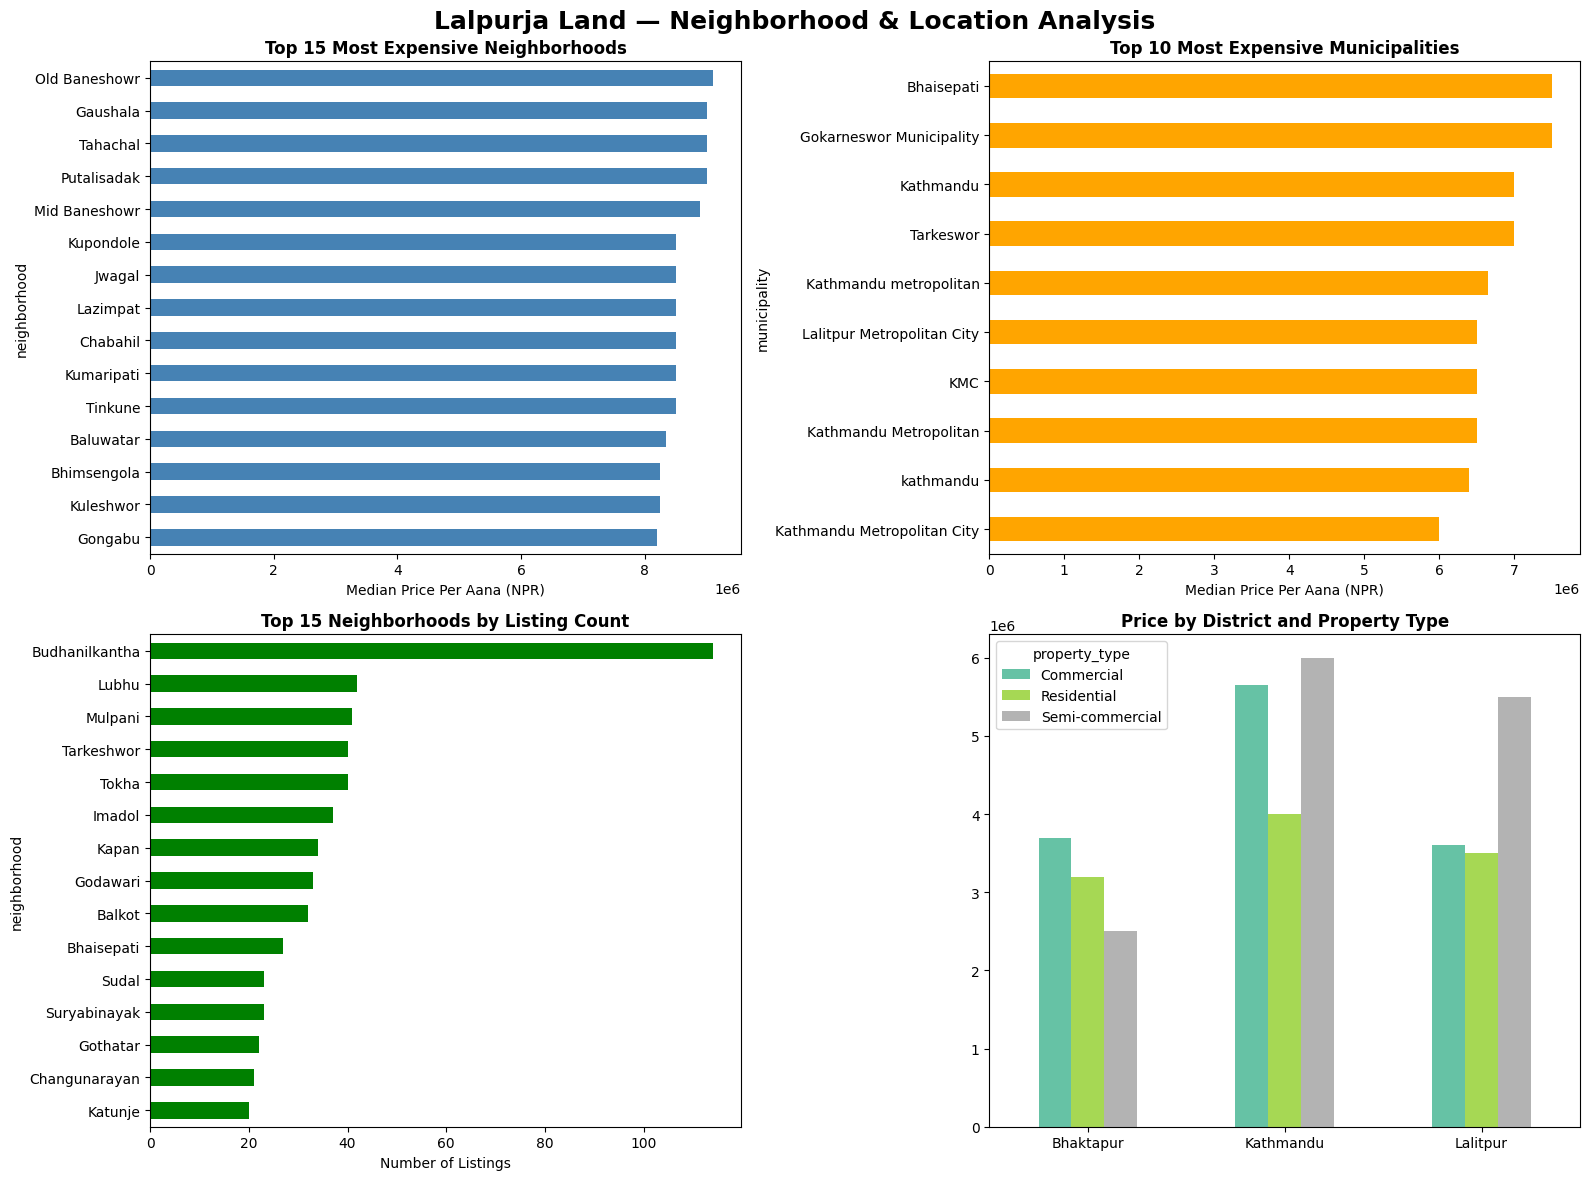

=== Top 15 Most Expensive Neighborhoods ===
neighborhood
Old Baneshowr    9100000.0
Gaushala         9000000.0
Tahachal         9000000.0
Putalisadak      9000000.0
Mid Baneshowr    8900000.0
Kupondole        8500000.0
Jwagal           8500000.0
Lazimpat         8500000.0
Chabahil         8500000.0
Kumaripati       8500000.0
Tinkune          8500000.0
Baluwatar        8350000.0
Bhimsengola      8250000.0
Kuleshwor        8250000.0
Gongabu          8200000.0
Name: price_per_aana, dtype: float64

=== Top 10 Municipalities by Price ===
municipality
Bhaisepati                     7500000.0
Gokarneswor Municipality       7500000.0
Kathmandu                      7000000.0
Tarkeswor                      7000000.0
Kathmandu metropolitan         6650000.0
Lalitpur Metropolitan City     6500000.0
KMC                            6500000.0
Kathmandu Metropolitan         6500000.0
kathmandu                      6400000.0
Kathmandu Metropolitan City    6000000.0
Name: price_per_aana, dtype: float64



In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Land — Neighborhood & Location Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Top 15 most expensive neighborhoods
# Why: Neighborhood is always a strong price signal
# Confirms which areas command premium prices
top_n = df_lp.groupby('neighborhood')['price_per_aana']\
    .median().sort_values(ascending=False).head(15)
top_n.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Top 15 Most Expensive Neighborhoods', fontweight='bold')
axes[0,0].set_xlabel('Median Price Per Aana (NPR)')
axes[0,0].invert_yaxis()

# Plot 2 — Price by municipality
# Why: Municipality is more granular than district
# Shows micro-market price differences within districts
top_mun = df_lp.groupby('municipality')['price_per_aana']\
    .median().sort_values(ascending=False).head(10)
top_mun.plot(kind='barh', ax=axes[0,1], color='orange')
axes[0,1].set_title('Top 10 Most Expensive Municipalities', fontweight='bold')
axes[0,1].set_xlabel('Median Price Per Aana (NPR)')
axes[0,1].invert_yaxis()

# Plot 3 — Listing count by neighborhood (top 15)
# Why: See which neighborhoods have most listings
# High listing count = more liquid market = more reliable price signal
top_n_count = df_lp['neighborhood'].value_counts().head(15)
top_n_count.plot(kind='barh', ax=axes[1,0], color='green')
axes[1,0].set_title('Top 15 Neighborhoods by Listing Count', fontweight='bold')
axes[1,0].set_xlabel('Number of Listings')
axes[1,0].invert_yaxis()

# Plot 4 — Price by district and property_type combined
# Why: See if commercial premium varies by district
# Some districts may value commercial land more than others
df_lp.groupby(['district', 'property_type'])['price_per_aana']\
    .median().unstack().plot(kind='bar', ax=axes[1,1], colormap='Set2')
axes[1,1].set_title('Price by District and Property Type', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].set_xlabel('')

plt.tight_layout()
plt.show()

# Key stats
print("=== Top 15 Most Expensive Neighborhoods ===")
print(top_n)

print("\n=== Top 10 Municipalities by Price ===")
print(top_mun)

print("\n=== Neighborhood count ===")
print(f"Total unique neighborhoods: {df_lp['neighborhood'].nunique()}")
print(f"Neighborhoods with < 3 listings: {(df_lp['neighborhood'].value_counts() < 3).sum()}")

print("\n=== Price by District and Property Type ===")
print(df_lp.groupby(['district','property_type'])['price_per_aana'].median().unstack())

In [11]:
# Fix municipality inconsistency
print("=== All municipality values ===")
print(df_lp['municipality'].value_counts().to_string())

=== All municipality values ===
municipality
Kathmandu                         144
Lalitpur                          112
Budhanilkantha                    110
Suryabinayak                      108
Mahalaxmi                          99
Changunarayan                      89
Tarkeshwor                         54
Tokha                              52
Godawari                           52
Madhyapur Thimi                    48
Nagarjun                           48
Kageshwori Manohara                43
Kageswori Manohara                 27
Gokarneshwor                       21
Chandragiri                        20
Budhanilkatha                      20
Bhaktapur                          17
Budanilkantha                      16
mahalaxmi                          14
KMC                                12
Budhanilkanta                      10
Suryavinayak                        9
lalitpur                            8
Kageshwori Manahora                 7
Gokarneswor                         5
godaw

In [12]:
# ─────────────────────────────────────────
# STANDARDIZE MUNICIPALITY NAMES
# Why: Same municipality has many different spellings
# due to inconsistent scraping. Must unify before encoding
# otherwise model treats them as different locations
# ─────────────────────────────────────────

municipality_map = {
    # Kathmandu variations
    'KMC':                              'Kathmandu',
    'kathmandu':                        'Kathmandu',
    'Kathmandu metropolitan':           'Kathmandu',
    'Kathmandu Metropolitan':           'Kathmandu',
    'Kathmandu Metropolitan City':      'Kathmandu',
    'Kathmandu Mahanagarpalika':        'Kathmandu',
    'Kathmandu Metropolitan':          'Kathmandu',

    # Budhanilkantha variations
    'Budhanilkanta':                    'Budhanilkantha',
    'Budanilkantha':                    'Budhanilkantha',
    'Budhanilkanta':                    'Budhanilkantha',
    'Budhanilakantha':                  'Budhanilkantha',
    'Budhanilatha':                     'Budhanilkantha',
    'Budanikantha':                     'Budhanilkantha',
    'budhanilkanta':                    'Budhanilkantha',
    'budhanilkantha':                   'Budhanilkantha',
    'Budhanilkantha Mahanagarpalika':   'Budhanilkantha',

    # Kageshwori Manohara variations
    'Kageswori Manohara':               'Kageshwori Manohara',
    'kageswori manohara':               'Kageshwori Manohara',
    'Kageshwori Manahora':              'Kageshwori Manohara',
    'Kageshwori Manhoara':              'Kageshwori Manohara',
    'Kageshwori Manahor':               'Kageshwori Manohara',
    'Kageshwari Manohara':              'Kageshwori Manohara',
    'Kageshwari-Manohara':              'Kageshwori Manohara',
    'Kageshwari':                       'Kageshwori Manohara',
    'Kageshwori Manahora':              'Kageshwori Manohara',
    'Kageswori manohara':               'Kageshwori Manohara',
    'Kageshowri':                       'Kageshwori Manohara',
    'Kageshowori Manahora':             'Kageshwori Manohara',
    'Kagehwori Manohara':               'Kageshwori Manohara',
    'Kaheswori Manohara':               'Kageshwori Manohara',
    'Kagashwori Manohara':              'Kageshwori Manohara',
    'Kageshwori':                       'Kageshwori Manohara',
    'Kageshwori Manahor':               'Kageshwori Manohara',
    'Kageshwari Manhora':               'Kageshwori Manohara',
    'Kagehswori Manohara':              'Kageshwori Manohara',
    'Kagehwori Manohara':               'Kageshwori Manohara',
    'Kageshwori Manhora':               'Kageshwori Manohara',

    # Gokarneshwor variations
    'Gokarneswor':                      'Gokarneshwor',
    'Gokarneshwar':                     'Gokarneshwor',
    'Gokarnashwor':                     'Gokarneshwor',
    'Gokernashwor':                     'Gokarneshwor',
    'Gokarneswor Municipality':         'Gokarneshwor',

    # Lalitpur variations
    'lalitpur':                         'Lalitpur',
    'Lalitpur Metropolitan City':       'Lalitpur',
    'Lalitpur Mahanagarpalika':         'Lalitpur',

    # Mahalaxmi variations
    'mahalaxmi':                        'Mahalaxmi',
    'Mahalaxmi Muncipality':            'Mahalaxmi',

    # Suryabinayak variations
    'Suryavinayak':                     'Suryabinayak',
    'Suryabinyak':                      'Suryabinayak',
    'Suryabianyak':                     'Suryabinayak',
    'suryabinayak':                     'Suryabinayak',
    'Suryabinayak Nagarpalika':         'Suryabinayak',
    'Suryabinayak Municipality':        'Suryabinayak',

    # Tarkeshwor variations
    'Tarkeswor':                        'Tarkeshwor',
    'Takeshwor':                        'Tarkeshwor',
    'tarkeshwor':                       'Tarkeshwor',
    'Tokha Nagarpalika':                'Tokha',

    # Changunarayan variations
    'Changunrayan':                     'Changunarayan',
    'Changuarayan':                     'Changunarayan',
    'ChanguNarayan':                    'Changunarayan',
    'Changunrayan':                     'Changunarayan',

    # Shankarapur variations
    'Shankharapur':                     'Shankarapur',
    'Shankarpur':                       'Shankarapur',
    'shankarapur':                      'Shankarapur',
    'Sankharpur':                       'Shankarapur',
    'Shankarapur Municipality':         'Shankarapur',

    # Godawari variations
    'godawari':                         'Godawari',

    # Kirtipur variations
    'kirtipur':                         'Kirtipur',
    'kirtipur nagarpalika':             'Kirtipur',

    # Madhyapur Thimi variations
    'Madyapur Thimi':                   'Madhyapur Thimi',
    'Mashyapur Thimi':                  'Madhyapur Thimi',
    'Madyapur Thimi':                   'Madhyapur Thimi',

    # Nagarjun variations
    'Nagarjuna':                        'Nagarjun',

    # Ichangu Narayan variations
    'Ichangunarayan':                   'Ichangu Narayan',

    # chandragiri variations
    'chandragiri':                      'Chandragiri',

    # Manamaiju variations
    'Manmaiju':                         'Manamaiju',

    # Bhaisepati — keep as is (single entry)
    # Boudha — keep as is
    # Kavresthali — keep as is
    # Jharuwarasi — keep as is
    # Dakshinkali — keep as is
    # Duwakot — keep as is
    # Bungmati — keep as is
    # Ramkot — keep as is
    # Balambu — keep as is
    # 07 — unknown, will handle separately
}

# Apply mapping
df_lp['municipality'] = df_lp['municipality'].replace(municipality_map)

# Handle '07' — unknown ward number in municipality field
df_lp['municipality'] = df_lp['municipality'].replace('07', 'Unknown')

print("=== Municipality after standardization ===")
print(df_lp['municipality'].value_counts().to_string())
print(f"\nTotal unique municipalities: {df_lp['municipality'].nunique()}")

=== Municipality after standardization ===
municipality
Kathmandu              165
Budhanilkantha         145
Suryabinayak           124
Lalitpur               122
Mahalaxmi              114
Kageshwori Manohara     95
Changunarayan           92
Tarkeshwor              57
Godawari                57
Tokha                   55
Madhyapur Thimi         50
Nagarjun                49
Gokarneshwor            32
Chandragiri             21
Budhanilkatha           20
Bhaktapur               17
Kirtipur                11
Shankarapur             10
Ramkot                   3
Ichangu Narayan          3
Purano Naikap            2
Manamaiju                2
Budhanilkanth            1
Bhand bhanjyang          1
Balambu                  1
Kalanki                  1
Boudha                   1
Kavresthali              1
Bungmati                 1
Unknown                  1
Dadapauwa                1
Dakshinkali              1
Bhaisepati               1
Jharuwarasi              1
Kavre                    1

In [13]:
# Fix remaining stragglers missed in first pass
straggler_map = {
    'Budhanilkatha':  'Budhanilkantha',
    'Budhanilkanth':  'Budhanilkantha',
}
df_lp['municipality'] = df_lp['municipality'].replace(straggler_map)

# Rare municipalities (count < 3) — assign to Unknown
# Why: Single entry municipalities add noise without signal
# Better to group them as Unknown than create unreliable encodings
mun_counts = df_lp['municipality'].value_counts()
rare_mun    = mun_counts[mun_counts < 3].index
df_lp['municipality'] = df_lp['municipality'].replace(rare_mun, 'Unknown')

print("=== Municipality after final fix ===")
print(df_lp['municipality'].value_counts().to_string())
print(f"\nTotal unique municipalities: {df_lp['municipality'].nunique()}")

=== Municipality after final fix ===
municipality
Budhanilkantha         166
Kathmandu              165
Suryabinayak           124
Lalitpur               122
Mahalaxmi              114
Kageshwori Manohara     95
Changunarayan           92
Tarkeshwor              57
Godawari                57
Tokha                   55
Madhyapur Thimi         50
Nagarjun                49
Gokarneshwor            32
Chandragiri             21
Bhaktapur               17
Unknown                 17
Kirtipur                11
Shankarapur             10
Ichangu Narayan          3
Ramkot                   3

Total unique municipalities: 20


C:\Users\DELL\AppData\Local\Temp\ipykernel_11236\1842657645.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lp[df_lp['property_face'].isin(valid_face)],
C:\Users\DELL\AppData\Local\Temp\ipykernel_11236\1842657645.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lp, x='negotiable', y='price_per_aana',


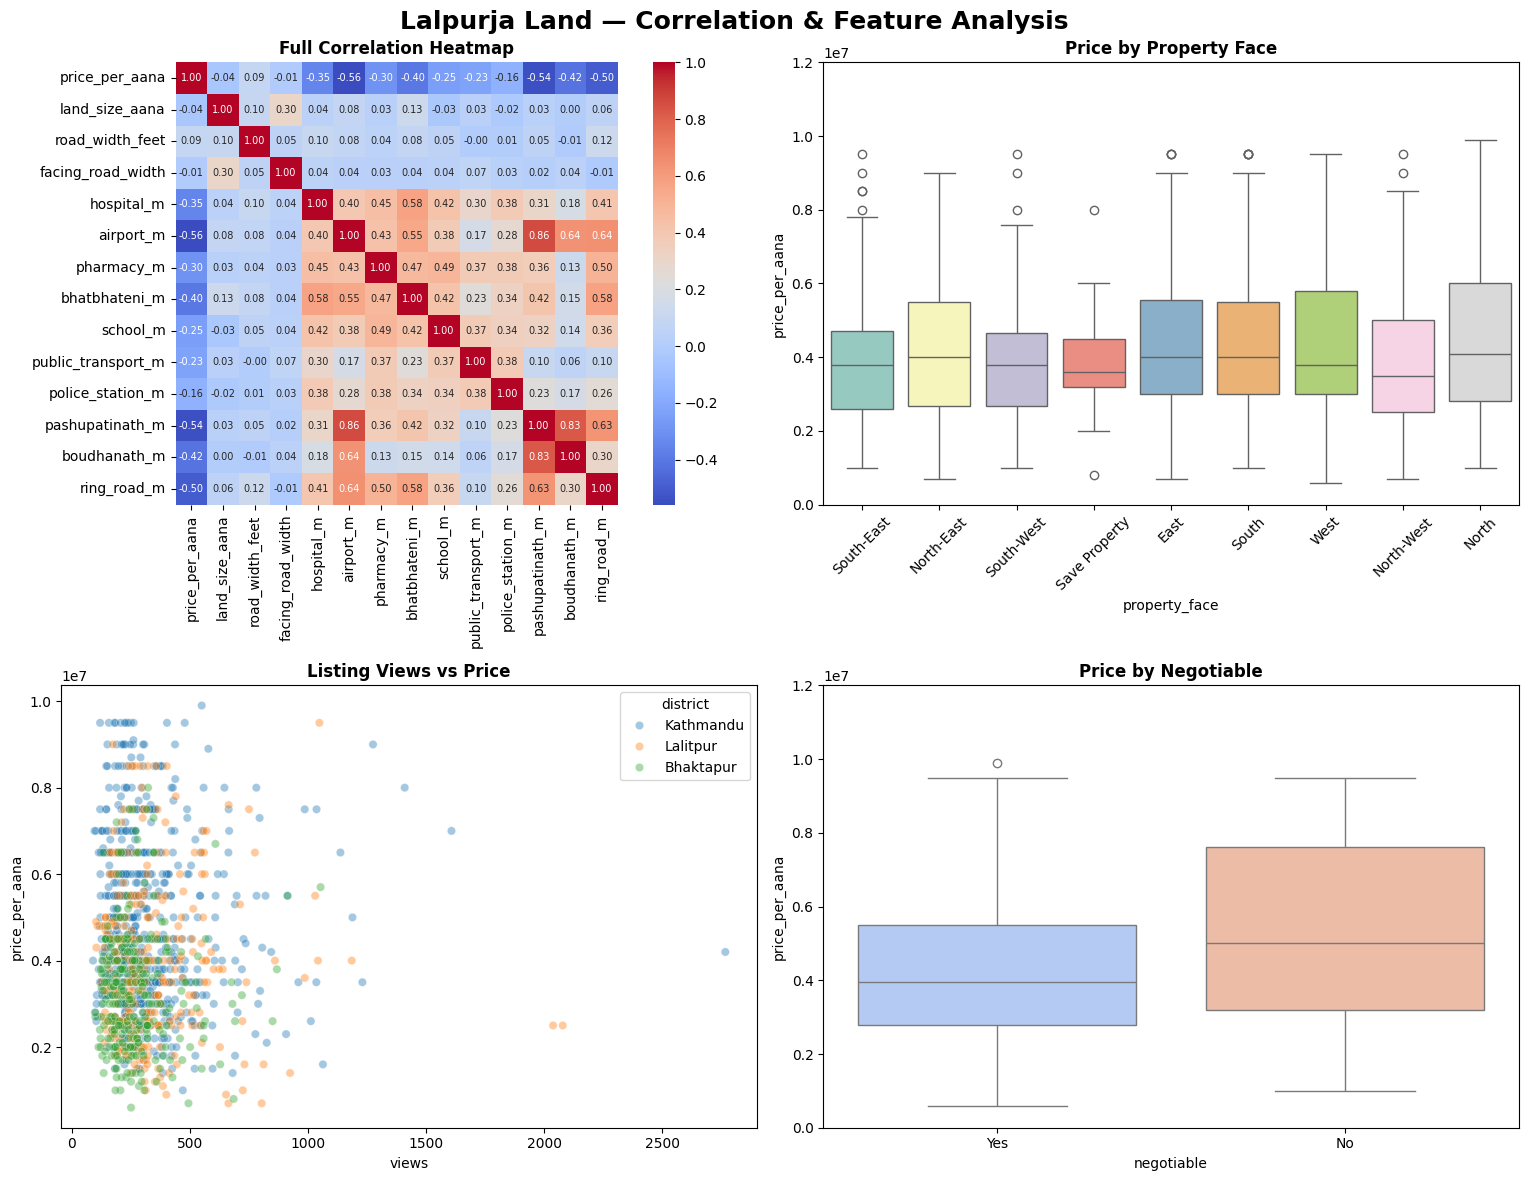

=== Price by property_face ===
property_face
North            4100000.0
East             4000000.0
North-East       4000000.0
South            4000000.0
South-East       3800000.0
South-West       3800000.0
West             3800000.0
Save Property    3600000.0
North-West       3500000.0
Name: price_per_aana, dtype: float64

=== Views correlation with price ===
Correlation: 0.0015

=== Price by negotiable ===
negotiable
No     5000000.0
Yes    3950000.0
Name: price_per_aana, dtype: float64

=== Multicollinearity check — amenity distances ===
High multicollinearity pairs (>0.7):
airport_m & pashupatinath_m: 0.863
pashupatinath_m & boudhanath_m: 0.828


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Lalpurja Land — Correlation & Feature Analysis', fontsize=18, fontweight='bold')

# Plot 1 — Full correlation heatmap
# Why: See relationships between ALL numerical features
# Helps identify multicollinearity between amenity distances
num_cols = ['price_per_aana', 'land_size_aana', 'road_width_feet',
            'facing_road_width', 'hospital_m', 'airport_m', 'pharmacy_m',
            'bhatbhateni_m', 'school_m', 'public_transport_m',
            'police_station_m', 'pashupatinath_m', 'boudhanath_m', 'ring_road_m']
corr = df_lp[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0,0], square=True, annot_kws={'size': 7})
axes[0,0].set_title('Full Correlation Heatmap', fontweight='bold')

# Plot 2 — Price by property_face
# Why: Check if plot facing direction affects price
# in this dataset compared to df_land
valid_face = df_lp['property_face'].value_counts()
valid_face = valid_face[valid_face >= 10].index
sns.boxplot(data=df_lp[df_lp['property_face'].isin(valid_face)],
            x='property_face', y='price_per_aana',
            ax=axes[0,1], palette='Set3')
axes[0,1].set_title('Price by Property Face', fontweight='bold')
axes[0,1].set_ylim(0, 12000000)
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 — Views vs price
# Why: More viewed listings may indicate more desirable
# and potentially higher priced properties
sns.scatterplot(data=df_lp, x='views', y='price_per_aana',
                hue='district', ax=axes[1,0], alpha=0.4)
axes[1,0].set_title('Listing Views vs Price', fontweight='bold')

# Plot 4 — Price by negotiable
# Why: Non-negotiable listings may have firmer/higher prices
sns.boxplot(data=df_lp, x='negotiable', y='price_per_aana',
            ax=axes[1,1], palette='coolwarm')
axes[1,1].set_title('Price by Negotiable', fontweight='bold')
axes[1,1].set_ylim(0, 12000000)

plt.tight_layout()
plt.show()

# Key stats
print("=== Price by property_face ===")
print(df_lp.groupby('property_face')['price_per_aana']\
      .median().sort_values(ascending=False))

print("\n=== Views correlation with price ===")
print(f"Correlation: {df_lp['views'].corr(df_lp['price_per_aana']):.4f}")

print("\n=== Price by negotiable ===")
print(df_lp.groupby('negotiable')['price_per_aana'].median())

print("\n=== Multicollinearity check — amenity distances ===")
amenity_cols = ['hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m',
                'school_m', 'public_transport_m', 'police_station_m',
                'pashupatinath_m', 'boudhanath_m', 'ring_road_m']
amenity_corr = df_lp[amenity_cols].corr()
# Show pairs with correlation above 0.7 — these are multicollinear
high_corr = []
for i in range(len(amenity_cols)):
    for j in range(i+1, len(amenity_cols)):
        val = amenity_corr.iloc[i,j]
        if abs(val) > 0.7:
            high_corr.append(f"{amenity_cols[i]} & {amenity_cols[j]}: {val:.3f}")
print("High multicollinearity pairs (>0.7):")
print('\n'.join(high_corr) if high_corr else "✅ No high multicollinearity")

In [15]:
# ─────────────────────────────────────────
# Fix 1 — Remove "Save Property" from property_face
# Why: "Save Property" is clearly a data entry error
# not a valid facing direction — 4 rows affected
# ─────────────────────────────────────────
print(f"Save Property rows: {(df_lp['property_face'] == 'Save Property').sum()}")
df_lp = df_lp[df_lp['property_face'] != 'Save Property'].reset_index(drop=True)
print(f"After removing Save Property: {df_lp.shape}")

Save Property rows: 46
After removing Save Property: (1214, 23)


In [16]:
# ─────────────────────────────────────────
# Fix 2 — Drop views column
# Why: Correlation with price is 0.0015 — essentially zero
# Adding it would only add noise to the model
# ─────────────────────────────────────────
df_lp.drop(columns=['views'], inplace=True)
print(f"After dropping views: {df_lp.shape}")

After dropping views: (1214, 22)


In [17]:
# ─────────────────────────────────────────
# Fix 3 — Drop one of the highly correlated pair
# airport_m & pashupatinath_m: 0.863
# pashupatinath_m & boudhanath_m: 0.828
# Why: Keep airport_m (strongest correlation with price -0.558)
# Drop pashupatinath_m and boudhanath_m to reduce multicollinearity
# Tree models can handle it but removing helps linear models too
# ─────────────────────────────────────────
df_lp.drop(columns=['pashupatinath_m', 'boudhanath_m'], inplace=True)
print(f"After dropping correlated columns: {df_lp.shape}")

print(f"\n=== Final columns ===")
print(list(df_lp.columns))

After dropping correlated columns: (1214, 20)

=== Final columns ===
['district', 'property_type', 'property_face', 'road_type', 'negotiable', 'municipality', 'ward_no', 'neighborhood', 'price_per_aana', 'land_size_aana', 'road_width_feet', 'facing_road_width', 'hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m', 'school_m', 'public_transport_m', 'police_station_m', 'ring_road_m']


In [18]:
# ─────────────────────────────────────────
# NEIGHBORHOOD ANALYSIS AND CLEANING
# Why: Same rare neighborhood problem as df_land
# Landmarks and business names slipped in as neighborhoods
# ─────────────────────────────────────────

print("=== Neighborhood stats ===")
print(f"Total unique neighborhoods: {df_lp['neighborhood'].nunique()}")
print(f"Neighborhoods with count < 3: {(df_lp['neighborhood'].value_counts() < 3).sum()}")
print(f"Neighborhoods with count >= 3: {(df_lp['neighborhood'].value_counts() >= 3).sum()}")

print("\n=== Top 20 neighborhoods ===")
print(df_lp['neighborhood'].value_counts().head(20))

print("\n=== Sample rare neighborhoods ===")
print(df_lp['neighborhood'].value_counts().tail(20))

=== Neighborhood stats ===
Total unique neighborhoods: 170
Neighborhoods with count < 3: 70
Neighborhoods with count >= 3: 100

=== Top 20 neighborhoods ===
neighborhood
Budhanilkantha         107
Lubhu                   41
Mulpani                 40
Tarkeshwor              37
Imadol                  37
Kapan                   34
Godawari                33
Balkot                  31
Tokha                   28
Bhaisepati              27
Sudal                   23
Suryabinayak            23
Gothatar                22
Changunarayan           21
Katunje                 20
Kageshwari-Manohara     18
Duwakot                 18
Kharipati               16
Sipadol                 16
Kirtipur                15
Name: count, dtype: int64

=== Sample rare neighborhoods ===
neighborhood
Tahachal        1
Ranibari        1
Gurujudhara     1
Satungal        1
Chhauni         1
Babarmahal      1
Putalisadak     1
Gaushala        1
Manbhawan       1
Kumaripati      1
Taukhel         1
Pulchowk        1


In [28]:
# ─────────────────────────────────────────
# FIX ROAD-LIKE NEIGHBORHOOD NAMES
# Dahachowk and Halchowk contain "chowk" which means
# intersection/square — these are location references
# not true neighborhood names. Reassign to price zones.
# ─────────────────────────────────────────

road_name_list = ['Dahachowk', 'Halchowk']

# Check their prices first before assigning zones
print("=== Road-like neighborhood prices ===")
for name in road_name_list:
    median = df_lp[df_lp['neighborhood'] == name]['price_per_aana'].median()
    count  = df_lp[df_lp['neighborhood'] == name].shape[0]
    print(f"{name}: {median:,.0f} NPR ({count} rows)")

# Reassign based on price zones
def price_to_zone(price):
    if price >= 7000000:   return 'Premium_Zone'
    elif price >= 5000000: return 'High_Zone'
    elif price >= 3500000: return 'Mid_Zone'
    elif price >= 2000000: return 'Budget_Zone'
    else:                  return 'Outskirt_Zone'

road_name_mapping = {}
for name in road_name_list:
    median = df_lp[df_lp['neighborhood'] == name]['price_per_aana'].median()
    road_name_mapping[name] = price_to_zone(median)

print("\n=== Road name → Zone mapping ===")
for name, zone in road_name_mapping.items():
    print(f"{name} → {zone}")

# Apply mapping
df_lp['neighborhood'] = df_lp['neighborhood'].replace(road_name_mapping)

# ─────────────────────────────────────────
# FINAL EDA SUMMARY — LALPURJA DATASET
# ─────────────────────────────────────────
print("\n=== Final dataset state ===")
print(f"Shape:                {df_lp.shape}")
print(f"Nulls:                {df_lp.isnull().sum().sum()}")
print(f"Unique neighborhoods: {df_lp['neighborhood'].nunique()}")
print(f"Unique municipalities:{df_lp['municipality'].nunique()}")
print(f"Districts:            {df_lp['district'].value_counts().to_dict()}")
print(f"Price range:          {df_lp['price_per_aana'].min():,.0f} – {df_lp['price_per_aana'].max():,.0f}")
print(f"Land size range:      {df_lp['land_size_aana'].min()} – {df_lp['land_size_aana'].max()} aana")

=== Road-like neighborhood prices ===
Dahachowk: 3,000,000 NPR (4 rows)
Halchowk: 3,200,000 NPR (3 rows)

=== Road name → Zone mapping ===
Dahachowk → Budget_Zone
Halchowk → Budget_Zone

=== Final dataset state ===
Shape:                (1214, 22)
Nulls:                0
Unique neighborhoods: 103
Unique municipalities:20
Districts:            {'Kathmandu': 643, 'Lalitpur': 292, 'Bhaktapur': 279}
Price range:          600,000 – 9,900,000
Land size range:      1.0 – 50.0 aana


In [20]:
df_lp.sample(10)

,district,property_type,property_face,road_type,negotiable,municipality,ward_no,neighborhood,price_per_aana,land_size_aana,road_width_feet,facing_road_width,hospital_m,airport_m,pharmacy_m,bhatbhateni_m,school_m,public_transport_m,police_station_m,ring_road_m
448,Kathmandu,Semi-commercial,East,High Access,Yes,Tarkeshwor,06,Tarkeshwor,3200000.0,6.50,26.0,61.0,1000.0,9000.0,500.0,3000.0,500.0,1.0,500.0,4000.0
1034,Bhaktapur,Residential,South,Low Access,Yes,Suryabinayak,06,Balkot,3400000.0,3.25,20.0,28.0,2000.0,7000.0,300.0,4000.0,300.0,200.0,300.0,5000.0
883,Lalitpur,Residential,South-East,High Access,Yes,Mahalaxmi,4,Imadol,4500000.0,3.50,13.0,78.0,200.0,4000.0,50.0,150.0,100.0,100.0,150.0,200.0
899,Lalitpur,Residential,East,Low Access,Yes,Lalitpur,1.4km,Naghdaha,2000000.0,6.00,13.0,27.0,3600.0,13000.0,1300.0,6600.0,1200.0,1200.0,1400.0,6400.0
451,Kathmandu,Residential,North-West,Low Access,Yes,Kageshwori Manohara,06,Mulpani,3000000.0,50.00,14.0,20.0,6000.0,7200.0,300.0,5000.0,300.0,50.0,1000.0,5000.0
3,Kathmandu,Residential,East,Low Access,Yes,Budhanilkantha,11,Kapan,4000000.0,4.00,13.0,34.0,400.0,8000.0,380.0,2000.0,350.0,600.0,800.0,5000.0
602,Kathmandu,Residential,East,High Access,Yes,Kathmandu,14,Kuleshwor,8000000.0,11.00,22.0,58.0,200.0,4000.0,100.0,1000.0,200.0,90.0,100.0,700.0
676,Lalitpur,Residential,South,High Access,Yes,Lalitpur,02,Sanepa,7200000.0,3.50,13.0,24.0,500.0,8000.0,300.0,300.0,100.0,200.0,200.0,4000.0
1211,Bhaktapur,Commercial,North,High Access,Yes,Madhyapur Thimi,01,Lokanthali,7500000.0,4.75,20.0,23.0,2000.0,2000.0,300.0,2500.0,300.0,50.0,400.0,900.0
703,Lalitpur,Residential,North,High Access,Yes,Godawari,04,Godawari,2400000.0,4.00,16.0,30.0,1000.0,13000.0,200.0,800.0,200.0,200.0,600.0,6000.0


In [30]:
# 1 — Ring Road Proximity Score
# Reciprocal log transform captures exponential value decay
# as distance from ring road increases
# Example: 500m → 1/log(501) = 0.161, 5000m → 1/log(5001) = 0.118
df_lp['ring_road_proximity'] = 1 / (np.log1p(df_lp['ring_road_m']))

# 2 — Commercial Road Width Interaction
# Wide road is essential for commercial land — not just nice to have
# Formula: is_commercial (0/1) × road_width_feet
# Non-commercial plots get 0, commercial plots get their road width value
df_lp['comm_road_premium'] = (
    (df_lp['property_type'] == 'Commercial').astype(int) * df_lp['road_width_feet']
)

# 3 — Corner Plot Proxy
# Diagonal facings (North-East, South-West etc.) indicate corner plots
# Corner plots have two-side road access — premium in Nepal market
# str.contains('-') detects compound directions like "North-East"
df_lp['is_corner_plot'] = df_lp['property_face'].str.contains('-').astype(int)

# 4 — Distance Floor Clipping
# Values like 1m or 2m are likely data entry errors
# Clip to 50m minimum — no urban amenity is realistically 1m away
dist_cols = [col for col in df_lp.columns if col.endswith('_m')]
df_lp[dist_cols] = df_lp[dist_cols].clip(lower=50)  # Fixed: df → df_lp


# ─────────────────────────────────────────
# VERIFY
# ─────────────────────────────────────────
print(f"Shape: {df_lp.shape}")
print(f"New features added: ring_road_proximity, comm_road_premium, is_corner_plot")
print(f"\n=== New feature stats ===")
print(df_lp[['ring_road_proximity', 'comm_road_premium', 'is_corner_plot']].describe())
print(f"\nCorner plots: {df_lp['is_corner_plot'].sum()} ({df_lp['is_corner_plot'].mean()*100:.1f}%)")
print(f"Commercial road premium > 0: {(df_lp['comm_road_premium'] > 0).sum()} rows")

Shape: (1214, 22)
New features added: ring_road_proximity, comm_road_premium, is_corner_plot

=== New feature stats ===
       ring_road_proximity  comm_road_premium  is_corner_plot
count          1214.000000        1214.000000     1214.000000
mean              0.130471           2.720041        0.395387
std               0.026075           8.226936        0.489135
min               0.099569           0.000000        0.000000
25%               0.114947           0.000000        0.000000
50%               0.120565           0.000000        0.000000
75%               0.131555           0.000000        1.000000
max               0.254335          60.000000        1.000000

Corner plots: 480 (39.5%)
Commercial road premium > 0: 144 rows


In [31]:
df_lp.sample(12)

,district,property_type,property_face,road_type,municipality,ward_no,neighborhood,price_per_aana,land_size_aana,road_width_feet,...,airport_m,pharmacy_m,bhatbhateni_m,school_m,public_transport_m,police_station_m,ring_road_m,ring_road_proximity,comm_road_premium,is_corner_plot
612,Kathmandu,Residential,South,High Access,Kathmandu,31,Premium_Zone,7500000.0,8.00,13.0,...,1000.0,100.0,500.0,100.0,100.0,1700.0,500.0,0.160859,0.0,0
713,Lalitpur,Residential,South-West,Low Access,Lalitpur,23,Hattiban,4000000.0,4.12,13.0,...,8400.0,700.0,2700.0,800.0,700.0,3000.0,2300.0,0.129181,0.0,1
593,Kathmandu,Residential,West,High Access,Nagarjun,Nagarjun Nagarpalika 1,Raniban,3800000.0,5.00,6.0,...,8000.0,200.0,3000.0,200.0,250.0,600.0,2000.0,0.131555,0.0,0
37,Kathmandu,Semi-commercial,North-West,High Access,Budhanilkantha,02,Chapali,5500000.0,1.00,26.0,...,7000.0,200.0,400.0,400.0,400.0,200.0,250.0,0.180981,0.0,1
67,Kathmandu,Residential,South-West,High Access,Budhanilkantha,01,Budhanilkantha,4800000.0,4.78,22.0,...,9000.0,500.0,7000.0,2000.0,600.0,500.0,3500.0,0.122537,0.0,1
166,Kathmandu,Residential,South-West,Low Access,Kathmandu,06,Boudha,5200000.0,5.00,8.0,...,7000.0,500.0,4000.0,300.0,200.0,500.0,4000.0,0.120565,0.0,1
353,Kathmandu,Residential,South,High Access,Chandragiri,02,Budget_Zone,2700000.0,3.25,13.0,...,10000.0,300.0,400.0,400.0,400.0,300.0,300.0,0.175220,0.0,0
893,Lalitpur,Residential,North-East,High Access,Lalitpur,25,Bhaisepati,5500000.0,3.50,20.0,...,10000.0,550.0,700.0,2100.0,150.0,200.0,1500.0,0.136726,0.0,1
1175,Bhaktapur,Residential,South-East,High Access,Madhyapur Thimi,02,Sanothimi,5500000.0,8.50,20.0,...,5500.0,300.0,1500.0,300.0,200.0,300.0,3000.0,0.124895,0.0,1
1176,Bhaktapur,Semi-commercial,North-East,Low Access,Bhaktapur,02,Duwakot,2000000.0,13.00,20.0,...,11000.0,1000.0,4000.0,3000.0,4000.0,2000.0,5000.0,0.117407,0.0,1


In [32]:
df=df_lp.copy()

In [33]:
df['negotiable'].value_counts()

KeyError: 'negotiable'

In [34]:
df.sample()

,district,property_type,property_face,road_type,municipality,ward_no,neighborhood,price_per_aana,land_size_aana,road_width_feet,...,airport_m,pharmacy_m,bhatbhateni_m,school_m,public_transport_m,police_station_m,ring_road_m,ring_road_proximity,comm_road_premium,is_corner_plot
285,Kathmandu,Residential,South-East,Low Access,Budhanilkantha,03,Budhanilkantha,3500000.0,34.0,13.0,...,11000.0,200.0,3000.0,500.0,500.0,500.0,3000.0,0.124895,0.0,1


In [36]:
pd.set_option('display.max_rows',None)

In [37]:
df_lp['ward_no'].value_counts()

ward_no
06                        117
08                        109
04                        102
02                        102
05                         84
07                         83
03                         80
01                         75
09                         75
10                         40
13                         31
11                         30
14                         28
31                         20
500m                       19
32                         18
15                         15
26                         13
18                         11
23                          9
200m                        9
25                          7
3                           6
28                          6
1                           6
2                           6
5                           6
16                          6
24                          6
12                          5
6                           5
22                          4
9                           4
1.

In [38]:
import re

# ─────────────────────────────────────────
# CLEAN WARD NUMBER COLUMN
# Why: ward_no should only contain numeric ward numbers (1-33)
# Anything else is a scraping error from wrong field
# ─────────────────────────────────────────

def clean_ward_no(val):
    val = str(val).strip()
    
    # If it contains distance units → clearly wrong field → NaN
    if any(unit in val.lower() for unit in ['km', 'm', 'kmc', 'nagarjun', 
                                             'mahalaxmi', 'nagarpalika']):
        return np.nan
    
    # Extract first number found
    match = re.search(r'\d+', val)
    if match:
        num = int(match.group())
        # Valid ward numbers in Nepal are 1-33
        if 1 <= num <= 33:
            return num
    return np.nan

df_lp['ward_no'] = df_lp['ward_no'].apply(clean_ward_no)

print("=== Ward no after cleaning ===")
print(df_lp['ward_no'].value_counts().sort_index())
print(f"\nNulls after cleaning: {df_lp['ward_no'].isnull().sum()}")
print(f"Valid ward numbers: {df_lp['ward_no'].notna().sum()}")

=== Ward no after cleaning ===
ward_no
1.0      82
2.0     108
3.0      86
4.0     106
5.0      90
6.0     122
7.0      86
8.0     110
9.0      79
10.0     40
11.0     30
12.0      5
13.0     31
14.0     28
15.0     15
16.0      6
17.0      2
18.0     11
19.0      2
21.0      3
22.0      4
23.0      9
24.0      6
25.0      7
26.0     13
27.0      3
28.0      6
29.0      3
31.0     20
32.0     18
33.0      1
Name: count, dtype: int64

Nulls after cleaning: 82
Valid ward numbers: 1132


In [43]:
pd.set_option('display.max_columns',None)

In [44]:
df_lp[df_lp['ward_no'].isna()]

,district,property_type,property_face,road_type,municipality,ward_no,neighborhood,price_per_aana,land_size_aana,road_width_feet,facing_road_width,hospital_m,airport_m,pharmacy_m,bhatbhateni_m,school_m,public_transport_m,police_station_m,ring_road_m,ring_road_proximity,comm_road_premium,is_corner_plot
487,Kathmandu,Commercial,South-West,High Access,Nagarjun,NaN,Bafal,7500000.0,18.00,13.0,55.0,500.0,11000.0,400.0,600.0,50.0,100.0,1700.0,700.0,0.152613,13.0,1
489,Kathmandu,Residential,North,Low Access,Budhanilkantha,NaN,Budhanilkantha,3500000.0,5.50,20.0,38.0,1000.0,7000.0,300.0,2000.0,500.0,500.0,500.0,2000.0,0.131555,0.0,0
490,Kathmandu,Residential,East,Low Access,Budhanilkantha,NaN,Budhanilkantha,3500000.0,5.50,20.0,34.0,1000.0,7000.0,500.0,1000.0,500.0,500.0,800.0,2000.0,0.131555,0.0,0
493,Kathmandu,Residential,South,High Access,Nagarjun,NaN,Sitapaila,3000000.0,10.00,13.0,30.0,500.0,13500.0,400.0,2000.0,500.0,500.0,1700.0,700.0,0.152613,0.0,0
499,Kathmandu,Residential,South-East,Low Access,Nagarjun,NaN,Kavresthali,2600000.0,4.75,13.0,32.0,1000.0,8000.0,500.0,8500.0,500.0,500.0,1000.0,2000.0,0.131555,0.0,1
506,Kathmandu,Residential,East,Low Access,Budhanilkantha,NaN,Budhanilkantha,4700000.0,4.00,10.0,35.0,100.0,6000.0,50.0,2000.0,500.0,50.0,500.0,2000.0,0.131555,0.0,0
507,Kathmandu,Residential,East,High Access,Gokarneshwor,NaN,Kapan,3800000.0,5.00,20.0,28.0,1000.0,5000.0,500.0,2000.0,500.0,500.0,500.0,4000.0,0.120565,0.0,0
511,Kathmandu,Residential,North-West,High Access,Budhanilkantha,NaN,Budhanilkantha,4000000.0,18.00,14.0,92.0,1000.0,6900.0,200.0,3000.0,200.0,200.0,300.0,4000.0,0.120565,0.0,1
513,Kathmandu,Residential,East,High Access,Tokha,NaN,Tarkeshwor,3500000.0,3.50,20.0,20.0,4000.0,16000.0,100.0,4000.0,100.0,100.0,1000.0,4000.0,0.120565,0.0,0
514,Kathmandu,Residential,East,Low Access,Tokha,NaN,Tarkeshwor,1900000.0,4.00,13.0,35.0,6000.0,16000.0,2000.0,6000.0,2000.0,1000.0,1000.0,6000.0,0.114947,0.0,0


In [46]:
# ─────────────────────────────────────────
# FILL WARD_NO NULLS USING VERIFIED WARD MAPPING
# Why: Instead of guessing with mode/median, we use
# actual verified ward numbers from internet research
# mapped by neighborhood name — much more accurate
# ─────────────────────────────────────────

ward_map = {
    # Nagarjun Municipality (Kathmandu District)
    'Bafal': 4,
    'Sitapaila': 4,
    'Kavresthali': 2,
    'Banasthali': 6,
    'Raniban': 1,
    'Naikap': 7,
    'Kalanki': 4,
    # Budhanilkantha Municipality (Kathmandu District)
    'Budhanilkantha': 3,
    # Gokarneshwor Municipality (Kathmandu District)
    'Kapan': 8,
    'Jorpati': 7,
    'Mulpani': 9,
    # Tokha Municipality (Kathmandu District)
    'Tarkeshwor': 10,
    # Suryabinayak Municipality (Bhaktapur District)
    'Balkot': 2,
    'Dadhikot': 4,
    # Mahalaxmi Municipality (Lalitpur District)
    'Imadol': 3,
    'Lubhu': 8,
    # Changunarayan Municipality (Bhaktapur District)
    'Changunarayan': 4,
    # Additional KTM localities
    'Lazimpat': 2,
    'Balaju': 16
}

# Step 1 — Apply ward map to fill nulls only
# Why only nulls: we don't want to overwrite already correct values
# We match on neighborhood column since ward_map is keyed by neighborhood
def fill_ward(row):
    # If ward_no is already filled — keep it
    if pd.notna(row['ward_no']):
        return row['ward_no']
    # If neighborhood is in our verified map — use that value
    if row['neighborhood'] in ward_map:
        return ward_map[row['neighborhood']]
    # Otherwise keep as NaN — will handle remaining below
    return np.nan

df_lp['ward_no'] = df_lp.apply(fill_ward, axis=1)

print(f"Nulls after ward_map fill: {df_lp['ward_no'].isnull().sum()}")

# Step 2 — Fill any remaining nulls with median per municipality
# Why: A small number may not be in our ward_map
# Municipality-level median is the next best guess
df_lp['ward_no'] = df_lp.groupby('municipality')['ward_no']\
    .transform(lambda x: x.fillna(x.median()))

# Step 3 — Convert to int
df_lp['ward_no'] = df_lp['ward_no'].astype(int)

# ─────────────────────────────────────────
# VERIFY
# ─────────────────────────────────────────
print(f"Nulls after all filling: {df_lp['ward_no'].isnull().sum()}")
print(f"dtype: {df_lp['ward_no'].dtype}")
print(f"\n=== Ward no distribution ===")
print(df_lp['ward_no'].value_counts().sort_index())

Nulls after ward_map fill: 37
Nulls after all filling: 0
dtype: int64

=== Ward no distribution ===
ward_no
1      85
2     114
3     101
4     112
5      98
6     129
7      91
8     118
9      82
10     42
11     30
12      5
13     38
14     28
15     15
16      7
17      2
18     22
19      2
21      3
22      4
23      9
24      6
25      7
26     13
27      3
28      6
29      3
31     20
32     18
33      1
Name: count, dtype: int64


In [47]:
# ─────────────────────────────────────────
# FINAL COMPREHENSIVE CHECK — LALPURJA DATASET
# ─────────────────────────────────────────

print("=== SHAPE & NULLS ===")
print(f"Shape: {df_lp.shape}")
print(f"Nulls: {df_lp.isnull().sum().sum()}")

print("\n=== DTYPES ===")
print(df_lp.dtypes)

print("\n=== CATEGORICAL COLUMNS ===")
for col in df_lp.select_dtypes(include='object').columns:
    print(f"\n--- {col} ---")
    print(df_lp[col].value_counts().head(10))

print("\n=== NUMERICAL COLUMNS ===")
print(df_lp.select_dtypes(include=['int64','float64']).describe().round(2).to_string())

print("\n=== PRICE CHECKS ===")
print(f"price_per_aana below 500k: {(df_lp['price_per_aana'] < 500000).sum()}")
print(f"price_per_aana above 15M:  {(df_lp['price_per_aana'] > 15000000).sum()}")

print("\n=== LAND SIZE CHECKS ===")
print(f"land_size_aana below 1:    {(df_lp['land_size_aana'] < 1).sum()}")
print(f"land_size_aana above 50:   {(df_lp['land_size_aana'] > 50).sum()}")

print("\n=== DISTANCE CHECKS ===")
dist_cols = [col for col in df_lp.columns if col.endswith('_m')]
for col in dist_cols:
    print(f"{col}: min={df_lp[col].min():.0f}m, max={df_lp[col].max():.0f}m")

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df_lp.duplicated().sum()}")

print("\n=== WARD NO RANGE ===")
print(f"Min: {df_lp['ward_no'].min()}, Max: {df_lp['ward_no'].max()}")
print(f"Any ward > 33: {(df_lp['ward_no'] > 33).sum()}")

=== SHAPE & NULLS ===
Shape: (1214, 22)
Nulls: 0

=== DTYPES ===
district                object
property_type           object
property_face           object
road_type               object
municipality            object
ward_no                  int64
neighborhood            object
price_per_aana         float64
land_size_aana         float64
road_width_feet        float64
facing_road_width      float64
hospital_m             float64
airport_m              float64
pharmacy_m             float64
bhatbhateni_m          float64
school_m               float64
public_transport_m     float64
police_station_m       float64
ring_road_m            float64
ring_road_proximity    float64
comm_road_premium      float64
is_corner_plot           int64
dtype: object

=== CATEGORICAL COLUMNS ===

--- district ---
district
Kathmandu    643
Lalitpur     292
Bhaktapur    279
Name: count, dtype: int64

--- property_type ---
property_type
Residential        965
Commercial         144
Semi-commercial    105


In [48]:
# One thing to verify — facing_road_width max 250 feet seems high
# A 250 feet wide facing road is extremely unusual
print("=== facing_road_width suspicious values ===")
print(f"Above 100 feet: {(df_lp['facing_road_width'] > 100).sum()}")
print(df_lp[df_lp['facing_road_width'] > 100][['neighborhood', 'municipality', 'facing_road_width']].head(10))

=== facing_road_width suspicious values ===
Above 100 feet: 13
        neighborhood    municipality  facing_road_width
90           Dhapasi           Tokha              130.0
184   Budhanilkantha  Budhanilkantha              140.0
214         Mid_Zone      Tarkeshwor              110.0
258           Ramkot        Nagarjun              250.0
264   Budhanilkantha  Budhanilkantha              200.0
755             Lele        Godawari              200.0
808         Hattiban        Lalitpur              164.0
1033          Balkot    Suryabinayak              175.0
1117   Changunarayan   Changunarayan              150.0
1137         Sirutar    Suryabinayak              168.0


In [49]:
# ─────────────────────────────────────────
# CAP FACING ROAD WIDTH
# Why: 250 feet facing road width is extreme
# Realistic maximum for urban Kathmandu valley
# is around 100 feet (major highways)
# Anything above is likely a data entry error
# ─────────────────────────────────────────
print("=== Before capping ===")
print(f"Max facing_road_width: {df_lp['facing_road_width'].max()} feet")
print(f"Above 100 feet: {(df_lp['facing_road_width'] > 100).sum()} rows")

# Cap at 100 feet — realistic maximum for urban plots
df_lp['facing_road_width'] = df_lp['facing_road_width'].clip(upper=100)

print("\n=== After capping ===")
print(f"Max facing_road_width: {df_lp['facing_road_width'].max()} feet")
print(f"Above 100 feet: {(df_lp['facing_road_width'] > 100).sum()} rows")
print(f"\nfacing_road_width stats:")
print(df_lp['facing_road_width'].describe().round(2))

=== Before capping ===
Max facing_road_width: 250.0 feet
Above 100 feet: 13 rows

=== After capping ===
Max facing_road_width: 100.0 feet
Above 100 feet: 0 rows

facing_road_width stats:
count    1214.00
mean       39.79
std        17.22
min         5.00
25%        29.00
50%        35.00
75%        46.00
max       100.00
Name: facing_road_width, dtype: float64


In [51]:
# ─────────────────────────────────────────
# SAVE FINAL CLEANED LALPURJA DATASET
# All issues resolved:
# - Municipality standardized (100+ variations → 20 clean names)
# - Neighborhood zones cleaned (170 → 103 meaningful names)
# - Ward numbers verified and filled (internet research + median imputation)
# - Distance columns converted to meters and capped
# - facing_road_width capped at 100 feet
# - New features added: ring_road_proximity, comm_road_premium, is_corner_plot
# - Zero nulls, zero duplicates, all ranges validated
# ─────────────────────────────────────────
df_lp.to_csv('cleaned_lalpurja_land_final_after_eda.csv', index=False)

print(f"✅ Saved cleaned_lalpurja_land_final__after_eda.csv")
print(f"✅ Shape: {df_lp.shape}")
print(f"✅ Nulls: {df_lp.isnull().sum().sum()}")
print(f"✅ Columns: {list(df_lp.columns)}")

✅ Saved cleaned_lalpurja_land_final__after_eda.csv
✅ Shape: (1214, 22)
✅ Nulls: 0
✅ Columns: ['district', 'property_type', 'property_face', 'road_type', 'municipality', 'ward_no', 'neighborhood', 'price_per_aana', 'land_size_aana', 'road_width_feet', 'facing_road_width', 'hospital_m', 'airport_m', 'pharmacy_m', 'bhatbhateni_m', 'school_m', 'public_transport_m', 'police_station_m', 'ring_road_m', 'ring_road_proximity', 'comm_road_premium', 'is_corner_plot']
